<a href="https://colab.research.google.com/github/sanjana19991118/python_ml/blob/main/Data_Preprocessing_Graded_Assignment_Sanjana_Vinay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Preprocessing and Dataset Preparation for Machine Learning



In [68]:
import pandas as pd
from tabulate import tabulate
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
df = pd.read_csv('/content/fifa21 datatset.csv')

In [30]:
# df

TASK A - Dataset Understanding



1.   Describe the Dataset
       

*   No of Records
*   No of features
*   Target Variable






In [31]:
print(df.shape)
# Number of Records in the Dataset
print('Number of Records', df.shape[0])

(18979, 77)
Number of Records 18979


In [32]:
# Length
print('Length', len(df))
print(df.describe())

Length 18979
                  ID           Age          ↓OVA           POT           BOV  \
count   18979.000000  18979.000000  18979.000000  18979.000000  18979.000000   
mean   226403.384794     25.194109     65.718636     71.136414     66.751726   
std     27141.054157      4.710520      6.968999      6.114635      6.747193   
min        41.000000     16.000000     47.000000     47.000000     48.000000   
25%    210135.000000     21.000000     61.000000     67.000000     62.000000   
50%    232418.000000     25.000000     66.000000     71.000000     67.000000   
75%    246922.500000     29.000000     70.000000     75.000000     71.000000   
max    259216.000000     53.000000     93.000000     95.000000     93.000000   

          Attacking      Crossing     Finishing  Heading Accuracy  \
count  18979.000000  18979.000000  18979.000000      18979.000000   
mean     248.938142     49.688392     45.842405         51.942726   
std       74.299428     18.131153     19.567081         17.

In [34]:
# Number of features
print("Total Features", df.shape[1])

Total Features 77


In [35]:
# Target Variable - ↓OVA (Overall Rating) is the target variable.
target = '↓OVA'
print("Target Variable:", target)

Target Variable: ↓OVA


In [36]:
# dtype_summary = df.dtypes.value_counts().reset_index()
# dtype_summary.columns = ['Dtype', 'Count']
# feature_df = pd.DataFrame({'Feature': df.columns, 'Data Type': df.dtypes.values, 'Unique Values': df.nunique().values})
# print(tabulate(feature_df, headers='keys', tablefmt='grid', showindex=False))


2.   Identify attribute types

Classify each feature into:
*   Nominal attributes
*   Ordinal attributes
*   Numeric attributes
      * Discrete
      * Continuous







In [37]:
# Feature Classification

nominal_attributes = [
    "ID", "Name", "LongName", "photoUrl", "playerUrl", "Nationality", "Club",
    "Positions", "Preferred Foot", "Best Position", "Joined", "Loan Date End", "Contract"
]

ordinal_attributes = [
    "W/F", "SM", "IR", "A/W", "D/W"
]

discrete_attributes = [
    "Age", "↓OVA", "POT", "BOV", "Attacking", "Crossing", "Finishing",
    "Heading Accuracy", "Short Passing", "Volleys", "Skill", "Dribbling",
    "Curve", "FK Accuracy", "Long Passing", "Ball Control", "Movement",
    "Acceleration", "Sprint Speed", "Agility", "Reactions", "Balance",
    "Power", "Shot Power", "Jumping", "Stamina", "Strength", "Long Shots",
    "Mentality", "Aggression", "Interceptions", "Positioning", "Vision",
    "Penalties", "Composure", "Defending", "Marking", "Standing Tackle",
    "Sliding Tackle", "Goalkeeping", "GK Diving", "GK Handling", "GK Kicking",
    "GK Positioning", "GK Reflexes", "Total Stats", "Base Stats", "PAC",
    "SHO", "PAS", "DRI", "DEF", "PHY", "Hits" # 'Hits' is discrete but needs cleaning from string format
]

continuous_attributes = [
    "Height",
    "Weight",
    "Value",
    "Wage",
    "Release Clause"
]

# 1. Summary Count Table
print("\n" + "="*55)
print(" Feature Classification Summary")
print("="*55)

summary = pd.DataFrame({
    'Attribute Type': ['Nominal', 'Ordinal', 'Numeric - Discrete', 'Numeric - Continuous', 'Total'],
    'Count': [len(nominal_attributes), len(ordinal_attributes),
            len(discrete_attributes), len(continuous_attributes),
              len(nominal_attributes) + len(ordinal_attributes) +
              len(discrete_attributes) + len(continuous_attributes)]
})

print(tabulate(summary, headers='keys', tablefmt='grid', showindex=False))

# -- 2. Nominal
print("\n Nominal attributes")
print(tabulate(pd.DataFrame({'#': range(1, len(nominal_attributes) + 1), 'Feature': nominal_attributes}),
               headers='keys', tablefmt='grid', showindex=False))

# -- 3. Ordinal
print("\n Ordinal attributes")
print(tabulate(pd.DataFrame({
    '#': range(1,len(ordinal_attributes)+1),
    'Feature': ordinal_attributes,
    'Order': ['1★–5★','1★–5★','1★–5★','Low→Med→High','Low→Med→High']
}), headers='keys', tablefmt='grid', showindex=False))

# ── 4. Numeric Discrete ────────────────────────────────────
print("\n NUMERIC — DISCRETE")
print(tabulate(pd.DataFrame({'#': range(1,len(discrete_attributes)+1), 'Feature': discrete_attributes}),
               headers='keys', tablefmt='grid', showindex=False))


# ── 5. Numeric Continuous ──────────────────────────────────
print("\n NUMERIC — CONTINUOUS")
print(tabulate(pd.DataFrame({
    '#': range(1,len(continuous_attributes)+1),
    'Feature': continuous_attributes,
    'Raw Format': ['170cm','72kg','€103.5M','€560K','€138.4M']
}), headers='keys', tablefmt='grid', showindex=False))


 Feature Classification Summary
+----------------------+---------+
| Attribute Type       |   Count |
+======================+=========+
| Nominal              |      13 |
+----------------------+---------+
| Ordinal              |       5 |
+----------------------+---------+
| Numeric - Discrete   |      54 |
+----------------------+---------+
| Numeric - Continuous |       5 |
+----------------------+---------+
| Total                |      77 |
+----------------------+---------+

 Nominal attributes
+-----+----------------+
|   # | Feature        |
+=====+================+
|   1 | ID             |
+-----+----------------+
|   2 | Name           |
+-----+----------------+
|   3 | LongName       |
+-----+----------------+
|   4 | photoUrl       |
+-----+----------------+
|   5 | playerUrl      |
+-----+----------------+
|   6 | Nationality    |
+-----+----------------+
|   7 | Club           |
+-----+----------------+
|   8 | Positions      |
+-----+----------------+
|   9 | Preferre

3. Provide a data dictionary table

Example format:

**Feature Type Description**

In [38]:

# ── Data Dictionary ─────────────────────────────────────
print("\n" + "="*55)
print("   DATA DICTIONARY")
print("="*55)

data_dict = [
  ["ID",               "Nominal",             "Unique FIFA player ID — not used for modelling"],
  ["Name",             "Nominal",             "Short display name of the player"],
  ["LongName",         "Nominal",             "Full legal name of the player"],
  ["photoUrl",         "Nominal (URL)",       "URL to player photo image"],
  ["playerUrl",        "Nominal (URL)",       "URL to player's sofifa profile page"],
  ["Nationality",      "Nominal",             "Player's country (164 unique values)"],
  ["Age",              "Discrete",            "Player age in years (range 16–53)"],
  ["↓OVA",            "Discrete — TARGET",   "Overall rating (0–100); main regression target"],
  ["POT",              "Discrete",            "Potential rating; max OVA a player can reach"],
  ["Club",             "Nominal",             "Current club name (682 unique clubs)"],
  ["Contract",         "Nominal",             "Contract period e.g. '2019 ~ 2023'"],
  ["Positions",        "Nominal",             "All positions the player can play e.g. ST, CB"],
  ["Height",           "Continuous*",         "Player height in cm (stored as string e.g. 170cm)"],
  ["Weight",           "Continuous*",         "Player weight in kg (stored as string e.g. 72kg)"],
  ["Preferred Foot",   "Nominal (Binary)",    "Dominant foot — Left or Right"],
  ["BOV",              "Discrete",            "Best OVA achieved in the player's best position"],
  ["Best Position",    "Nominal",             "Best position on pitch (15 categories e.g. ST, GK)"],
  ["Joined",           "Nominal (Date)",      "Date the player joined their current club"],
  ["Loan Date End",    "Nominal (Date)",      "End date of loan spell (if applicable)"],
  ["Value",            "Continuous*",         "Market value in euros e.g. €103.5M"],
  ["Wage",             "Continuous*",         "Weekly wage in euros e.g. €560K"],
  ["Release Clause",   "Continuous*",         "Release clause fee in euros"],
  ["Attacking",        "Discrete",            "Composite score of all attacking sub-attributes"],
  ["Crossing",         "Discrete",            "Cross delivery accuracy (0–100)"],
  ["Finishing",        "Discrete",            "Goal-scoring finishing ability (0–100)"],
  ["Heading Accuracy", "Discrete",            "Accuracy when heading the ball (0–100)"],
  ["Short Passing",    "Discrete",            "Short pass accuracy (0–100)"],
  ["Volleys",          "Discrete",            "Volley striking ability (0–100)"],
  ["Skill",            "Discrete",            "Composite score of all skill sub-attributes"],
  ["Dribbling",        "Discrete",            "Ball dribbling ability (0–100)"],
  ["Curve",            "Discrete",            "Ability to curve or bend the ball (0–100)"],
  ["FK Accuracy",      "Discrete",            "Free kick accuracy (0–100)"],
  ["Long Passing",     "Discrete",            "Long pass accuracy (0–100)"],
  ["Ball Control",     "Discrete",            "First touch and ball control (0–100)"],
  ["Movement",         "Discrete",            "Composite score of all movement sub-attributes"],
  ["Acceleration",     "Discrete",            "Rate of speed increase (0–100)"],
  ["Sprint Speed",     "Discrete",            "Maximum running speed (0–100)"],
  ["Agility",          "Discrete",            "Quickness of turns and movement (0–100)"],
  ["Reactions",        "Discrete",            "Reaction speed to in-game events (0–100)"],
  ["Balance",          "Discrete",            "Balance while moving or dribbling (0–100)"],
  ["Power",            "Discrete",            "Composite score of all power sub-attributes"],
  ["Shot Power",       "Discrete",            "Power behind a shot (0–100)"],
  ["Jumping",          "Discrete",            "Jump height and timing (0–100)"],
  ["Stamina",          "Discrete",            "Endurance over 90 minutes (0–100)"],
  ["Strength",         "Discrete",            "Physical strength in duels (0–100)"],
  ["Long Shots",       "Discrete",            "Long-range shot accuracy (0–100)"],
  ["Mentality",        "Discrete",            "Composite score of all mentality sub-attributes"],
  ["Aggression",       "Discrete",            "Aggression in tackles and duels (0–100)"],
  ["Interceptions",    "Discrete",            "Ability to intercept passes (0–100)"],
  ["Positioning",      "Discrete",            "Attacking positional awareness (0–100)"],
  ["Vision",           "Discrete",            "Ability to spot passing opportunities (0–100)"],
  ["Penalties",        "Discrete",            "Penalty kick accuracy (0–100)"],
  ["Composure",        "Discrete",            "Calmness under pressure (0–100)"],
  ["Defending",        "Discrete",            "Composite score of all defending sub-attributes"],
  ["Marking",          "Discrete",            "Ability to mark opponents (0–100)"],
  ["Standing Tackle",  "Discrete",            "Standing tackle accuracy (0–100)"],
  ["Sliding Tackle",   "Discrete",            "Sliding tackle accuracy (0–100)"],
  ["Goalkeeping",      "Discrete",            "Composite score of all GK sub-attributes"],
  ["GK Diving",        "Discrete",            "Goalkeeper diving ability (0–100)"],
  ["GK Handling",      "Discrete",            "Goalkeeper ball handling (0–100)"],
  ["GK Kicking",       "Discrete",            "Goalkeeper kicking ability (0–100)"],
  ["GK Positioning",   "Discrete",            "Goalkeeper positioning awareness (0–100)"],
  ["GK Reflexes",      "Discrete",            "Goalkeeper reflex speed (0–100)"],
  ["Total Stats",      "Discrete",            "Sum of all individual skill ratings"],
  ["Base Stats",       "Discrete",            "Sum of 6 core stats: PAC+SHO+PAS+DRI+DEF+PHY"],
  ["W/F",              "Ordinal",             "Weak foot rating: 1★ to 5★"],
  ["SM",               "Ordinal",             "Skill moves rating: 1★ to 5★"],
  ["A/W",              "Ordinal",             "Attacking work rate: Low / Medium / High"],
  ["D/W",              "Ordinal",             "Defensive work rate: Low / Medium / High"],
  ["IR",               "Ordinal",             "International reputation: 1★ to 5★"],
  ["PAC",              "Discrete",            "Pace — composite of Acceleration & Sprint Speed"],
  ["SHO",              "Discrete",            "Shooting — composite of shooting attributes"],
  ["PAS",              "Discrete",            "Passing — composite of passing attributes"],
  ["DRI",              "Discrete",            "Dribbling — composite of dribbling attributes"],
  ["DEF",              "Discrete",            "Defending — composite of defending attributes"],
  ["PHY",              "Discrete",            "Physicality — composite of physical attributes"],
  ["Hits",             "Discrete*",           "Times player was searched on sofifa.com"],
]

dd = pd.DataFrame(data_dict, columns=['Feature', 'Type', 'Description'])
print(tabulate(dd, headers='keys', tablefmt='grid', showindex=False, maxcolwidths=[20, 22, 48]))
print("\n* = Stored as string in raw data; requires cleaning before numeric use.")


   DATA DICTIONARY
+------------------+-------------------+--------------------------------------------------+
| Feature          | Type              | Description                                      |
+==================+===================+==================================================+
| ID               | Nominal           | Unique FIFA player ID — not used for modelling   |
+------------------+-------------------+--------------------------------------------------+
| Name             | Nominal           | Short display name of the player                 |
+------------------+-------------------+--------------------------------------------------+
| LongName         | Nominal           | Full legal name of the player                    |
+------------------+-------------------+--------------------------------------------------+
| photoUrl         | Nominal (URL)     | URL to player photo image                        |
+------------------+-------------------+--------------------

Task B - Data Quality Analysis

1. Missing Values

*   Count missing values per column
*   Visualize using heatmap or table

In [39]:
# ─── Style ───────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'axes.edgecolor': '#444',
    'grid.color': '#333',
    'axes.titlecolor': 'white',
})

BLUE   = '#4e9af1'
ORANGE = '#f4a261'
GREEN  = '#2ec4b6'
RED    = '#e63946'
PURPLE = '#9b59b6'
GOLD   = '#f6c90e'

In [40]:
total_cells    = df.shape[0] * df.shape[1]
total_missing  = df.isnull().sum().sum()
total_complete = total_cells - total_missing

In [41]:
print(f"\n DATASET OVERVIEW")
print(f"  Total Records       : {df.shape[0]}")
print(f"  Total Features      : {df.shape[1]}")
print(f"  Total Cells         : {total_cells}")
print(f"  Total Missing Cells : {total_missing}")
print(f"  Complete Cells      : {total_complete}")
print(f"  Missing Percentage  : {round((total_missing / total_cells) * 100, 2)}%")


 DATASET OVERVIEW
  Total Records       : 18979
  Total Features      : 77
  Total Cells         : 1461383
  Total Missing Cells : 20561
  Complete Cells      : 1440822
  Missing Percentage  : 1.41%


In [42]:
print(f"\n MISSING VALUES PER COLUMN")

missing_df = pd.DataFrame({
    'Feature'          : df.columns,
    'Total Records'    : df.shape[0],
    'Missing Count'    : df.isnull().sum().values,
    'Missing %'        : round((df.isnull().sum() / df.shape[0]) * 100, 2).values,
    'Non-Missing Count': df.notnull().sum().values,
    'Data Type'        : df.dtypes.values
})

 # Sort by missing count descending
missing_df = missing_df.sort_values('Missing Count', ascending=False).reset_index(drop=True)

print(tabulate(missing_df, headers='keys', tablefmt='grid', showindex=False))

# Columns WITH missing values only
print(f"\n COLUMNS WITH MISSING VALUES ONLY")

has_missing = missing_df[missing_df['Missing Count'] > 0]

if has_missing.empty:
    print(" No missing values found in the dataset.")
else:
    print(f"  Total columns with missing values: {len(has_missing)}")
    print(tabulate(has_missing, headers='keys', tablefmt='grid', showindex=False))

# Columns with NO missing values
no_missing = missing_df[missing_df['Missing Count'] == 0]
print(f"\n COLUMNS WITH NO MISSING VALUES : {len(no_missing)}")
print(tabulate(no_missing[['Feature','Missing Count','Missing %']],
               headers='keys', tablefmt='grid', showindex=False))

# Missing value severity classification
print(f"\n MISSING VALUE SEVERITY CLASSIFICATION")

def classify(pct):
    if pct == 0:
        return 'No Missing'
    elif pct <= 5:
        return 'Low  (≤5%)'
    elif pct <= 20:
        return 'Medium (6–20%)'
    else:
        return 'High  (>20%)'

missing_df['Severity'] = missing_df['Missing %'].apply(classify)

severity_summary = missing_df.groupby('Severity')['Feature'].count().reset_index()
severity_summary.columns = ['Severity', 'No. of Features']
print(tabulate(severity_summary, headers='keys', tablefmt='grid', showindex=False))


 MISSING VALUES PER COLUMN
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Feature          |   Total Records |   Missing Count |   Missing % |   Non-Missing Count | Data Type   |
+==================+=================+=================+=============+=====================+=============+
| Loan Date End    |           18979 |           17966 |       94.66 |                1013 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Hits             |           18979 |            2595 |       13.67 |               16384 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| LongName         |           18979 |               0 |        0    |               18979 | object      |
+------------------+-----------------+-----------------+-------------+---------------------+-------------+
| Name   

Visualize using heatmap or table


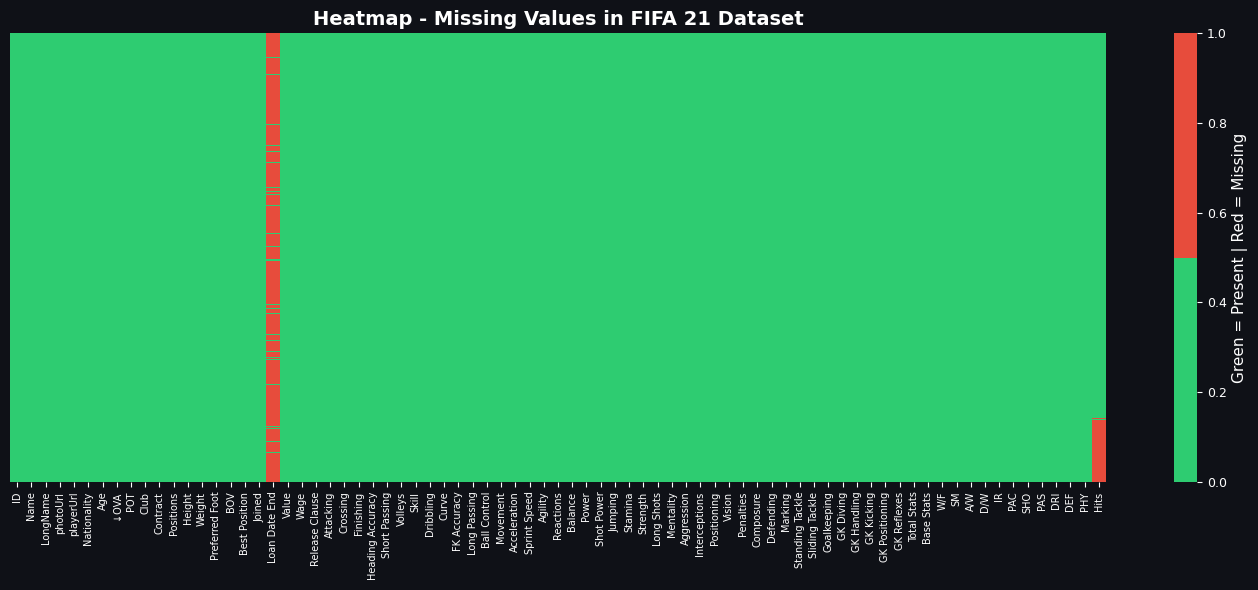

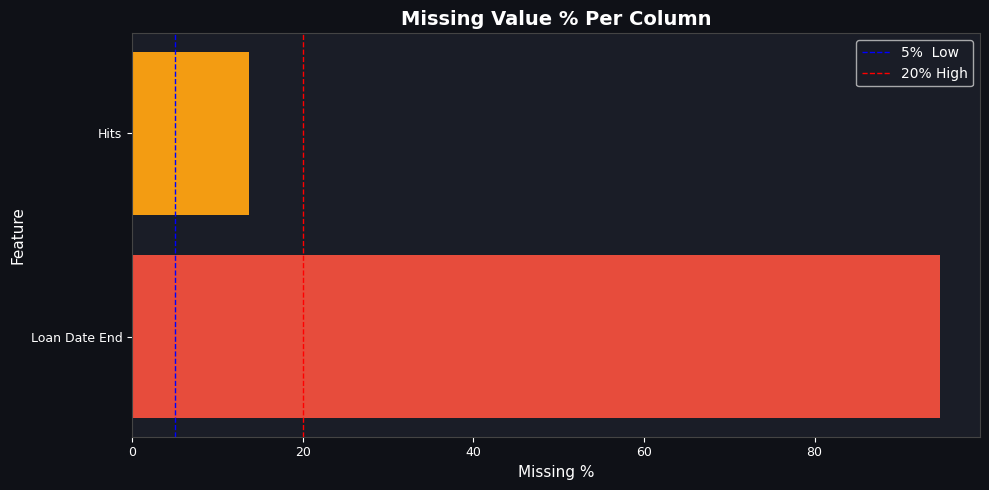

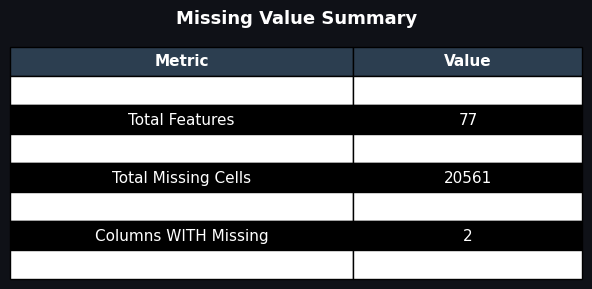

In [43]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# %matplotlib inline

# ── Missing value dataframe ───────────────────────────────
missing_count   = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Feature'      : missing_count.index,
    'Missing Count': missing_count.values,
    'Missing %'    : round(missing_percent, 2).values
}).sort_values('Missing %', ascending=False).reset_index(drop=True)

has_missing = missing_df[missing_df['Missing Count'] > 0]

# ── Heatmap ──────────────────────────────────────
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(),
            cmap=['#2ecc71','#e74c3c'],
            cbar_kws={'label': 'Green = Present | Red = Missing'},
            yticklabels=False,
            xticklabels=True)
plt.title('Heatmap - Missing Values in FIFA 21 Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# ── Bar chart ────────────────────────────────────
if has_missing.empty:
    print("No missing values found!")
else:
    plt.figure(figsize=(10, 5))
    colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#3498db'
              for p in has_missing['Missing %']]
    plt.barh(has_missing['Feature'], has_missing['Missing %'], color=colors)
    plt.axvline(x=5,  color='blue',  linestyle='--', linewidth=1, label='5%  Low')
    plt.axvline(x=20, color='red',   linestyle='--', linewidth=1, label='20% High')
    plt.title('Missing Value % Per Column', fontsize=14, fontweight='bold')
    plt.xlabel('Missing %')
    plt.ylabel('Feature')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ── Summary Table ────────────────────────────────
total_cells   = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()

summary_data = {
    'Metric': ['Total Records', 'Total Features', 'Total Cells',
               'Total Missing Cells', 'Overall Missing %',
               'Columns WITH Missing', 'Columns WITHOUT Missing'],
    'Value' : [df.shape[0], df.shape[1], total_cells,
               total_missing, f"{(total_missing/total_cells)*100:.2f}%",
               len(has_missing), df.shape[1] - len(has_missing)]
}

plt.figure(figsize=(6, 3))
plt.axis('off')
table = plt.table(
    cellText  = list(zip(summary_data['Metric'], summary_data['Value'])),
    colLabels = ['Metric', 'Value'],
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.6, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for col in range(2):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')
for row in range(1, 8):
    for col in range(2):
        table[row, col].set_facecolor('black' if row % 2 == 0 else '#ffffff')

plt.title('Missing Value Summary', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Duplicate Records
*   Identify duplicate rows
*   Remove duplicates if necessary

In [44]:
# ── 1. Total duplicate rows ───────────────────────────────
total_duplicates = df.duplicated().sum()
total_records    = df.shape[0]

print("=" * 55)
print("   DUPLICATE ROW DETECTION")
print("=" * 55)
print(f"\n  Total Records        : {total_records}")
print(f"  Duplicate Rows       : {total_duplicates}")
print(f"  Unique Rows          : {total_records - total_duplicates}")
print(f"  Duplicate %          : {round((total_duplicates / total_records) * 100, 2)}%")

# ── 2. Show duplicate rows ────────────────────────────────
if total_duplicates == 0:
    print("\n  No duplicate rows found in the dataset.")
else:
    print(f"\n  Found {total_duplicates} duplicate rows:")
    duplicate_rows = df[df.duplicated(keep=False)]
    print(duplicate_rows)

# ── 3. Check duplicates based on key column (ID / Name) ──
print("\n" + "=" * 55)
print("   DUPLICATE CHECK ON KEY COLUMNS")
print("=" * 55)

key_columns = ['ID', 'Name', 'LongName']

for col in key_columns:
    dup_count = df.duplicated(subset=[col]).sum()
    print(f"\n  Column  : {col}")
    print(f"  Duplicates : {dup_count}")
    if dup_count > 0:
        print(f"Duplicate values found in '{col}':")
        print(df[df.duplicated(subset=[col], keep=False)][['ID','Name','LongName']].head(10))
    else:
        print(f"No duplicates in '{col}'")


  # ── Summary ───────────────────────────────────────────────
print("\n" + "=" * 65)
print("   SUMMARY")
print("=" * 65)
print("""
  ALL 77 columns
  Result : No full duplicate rows

  NAME column only
  Result : Duplicates found

  Reason : Same player appears more than once in the dataset
           but with DIFFERENT values in other columns
           (e.g. different Club, Wage, Contract)
""")

   DUPLICATE ROW DETECTION

  Total Records        : 18979
  Duplicate Rows       : 0
  Unique Rows          : 18979
  Duplicate %          : 0.0%

  No duplicate rows found in the dataset.

   DUPLICATE CHECK ON KEY COLUMNS

  Column  : ID
  Duplicates : 0
No duplicates in 'ID'

  Column  : Name
  Duplicates : 1059
Duplicate values found in 'Name':
         ID         Name                    LongName
23   202126      H. Kane                  Harry Kane
45   176580    L. Suárez                 Luis Suárez
48   189596    T. Müller               Thomas Müller
59   143076     A. Gómez             Alejandro Gómez
62   231866        Rodri  Rodrigo Hernández Cascante
88   189509       Thiago            Thiago Alcântara
89   188377    K. Walker                 Kyle Walker
101  226753     A. Onana                 André Onana
104  231478  L. Martínez            Lautaro Martínez
112  211300   A. Martial             Anthony Martial

  Column  : LongName
  Duplicates : 127
Duplicate values found i

Remove duplicates if necessary

In [45]:
# ── Before ────────────────────────────────────────────────
print(f"Shape BEFORE : {df.shape}")
print(f"Full duplicate rows  : {df.duplicated().sum()}")
print(f"Duplicate Names      : {df.duplicated(subset=['Name']).sum()}")
print(f"Duplicate LongNames  : {df.duplicated(subset=['LongName']).sum()}")
print(f"Duplicate IDs        : {df.duplicated(subset=['ID']).sum()}")

# ── Remove full duplicate rows ────────────────────────────
df = df.drop_duplicates()

# ── Remove duplicate Names — keep highest OVA ─────────────
df = df.sort_values('↓OVA', ascending=False) \
       .drop_duplicates(subset=['Name'], keep='first') \
       .reset_index(drop=True)

# ── After ─────────────────────────────────────────────────
print(f"\nShape AFTER  : {df.shape}")
print(f"Full duplicate rows  : {df.duplicated().sum()}")
print(f"Duplicate Names      : {df.duplicated(subset=['Name']).sum()}")
print(f"Duplicate LongNames  : {df.duplicated(subset=['LongName']).sum()}")
print(f"Duplicate IDs        : {df.duplicated(subset=['ID']).sum()}")

print("\n Duplicates removed successfully!")

Shape BEFORE : (18979, 77)
Full duplicate rows  : 0
Duplicate Names      : 1059
Duplicate LongNames  : 127
Duplicate IDs        : 0

Shape AFTER  : (17920, 77)
Full duplicate rows  : 0
Duplicate Names      : 0
Duplicate LongNames  : 1
Duplicate IDs        : 0

 Duplicates removed successfully!


Noisy Data
*   Invalid values
*   Out-of-range numbers
*   Inconsistent categorical labels

In [46]:
print("=" * 60)
print("   NOISY DATA CLEANING")
print("=" * 60)
print(f"\n  Shape BEFORE : {df.shape}")

# ─────────────────────────────────────────────
# 1. CLEAN NUMERIC COLUMNS (Height, Weight,
#    Value, Wage, Release Clause, Hits)
# ─────────────────────────────────────────────
print("\n── Step 1 : Convert String Columns to Numeric ──")

# Height : '170cm' → 170
df['Height'] = df['Height'].str.replace('cm','').str.strip()
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')
print(f"  Height    cleaned  sample: {df['Height'].head(3).tolist()}")

# Weight : '72kg' → 72
df['Weight'] = df['Weight'].str.replace('kg','').str.strip()
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
print(f"  Weight    cleaned  sample: {df['Weight'].head(3).tolist()}")

# Value : '€103.5M' → 103500000
def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

df['Value']          = df['Value'].apply(parse_currency)
df['Wage']           = df['Wage'].apply(parse_currency)
df['Release Clause'] = df['Release Clause'].apply(parse_currency)
print(f"  Value     cleaned  sample: {df['Value'].head(3).tolist()}")
print(f"  Wage      cleaned  sample: {df['Wage'].head(3).tolist()}")
print(f"  Release Clause cleaned ")

# Hits : remove commas '1,200' → 1200
df['Hits'] = df['Hits'].astype(str).str.replace(',','').str.strip()
df['Hits'] = pd.to_numeric(df['Hits'], errors='coerce')
print(f"  Hits      cleaned sample: {df['Hits'].head(3).tolist()}")

# W/F, SM, IR : '4 ★' / '4★' → 4
for col in ['W/F', 'SM', 'IR']:
    df[col] = df[col].astype(str).str.replace('★','').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
print(f"  W/F, SM, IR cleaned sample W/F: {df['W/F'].head(3).tolist()}")

# ─────────────────────────────────────────────
# 2. INVALID VALUES
#    Replace anything that cannot be converted
#    to numeric with NaN (errors='coerce' above
#    already handles this)
# ─────────────────────────────────────────────
print("\n── Step 2 : Invalid Values ──")

numeric_cols = ['Height','Weight','Value','Wage','Release Clause',
                'Hits','W/F','SM','IR']

for col in numeric_cols:
    invalid = df[col].isnull().sum()
    print(f"  {col:<20} → {invalid} invalid/null values")

# ─────────────────────────────────────────────
# 3. OUT-OF-RANGE NUMBERS
#    Ratings must be 0–100
#    Age must be 15–50
#    Height must be 140–220 cm
#    Weight must be 40–120 kg
#    W/F, SM, IR must be 1–5
# ─────────────────────────────────────────────
print("\n── Step 3 : Out-of-Range Values ──")

rating_cols = ['↓OVA','POT','BOV','Crossing','Finishing','Heading Accuracy',
               'Short Passing','Volleys','Dribbling','Curve','FK Accuracy',
               'Long Passing','Ball Control','Acceleration','Sprint Speed',
               'Agility','Reactions','Balance','Shot Power','Jumping',
               'Stamina','Strength','Long Shots','Aggression','Interceptions',
               'Positioning','Vision','Penalties','Composure','Marking',
               'Standing Tackle','Sliding Tackle','GK Diving','GK Handling',
               'GK Kicking','GK Positioning','GK Reflexes',
               'PAC','SHO','PAS','DRI','DEF','PHY']

# Ratings 0–100
for col in rating_cols:
    out = df[(df[col] < 0) | (df[col] > 100)].shape[0]
    if out > 0:
        print(f" {col} has {out} out-of-range values → setting to NaN")
        df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
    else:
        print(f" {col:<25} range OK (0–100)")

# Age 15–50
out_age = df[(df['Age'] < 15) | (df['Age'] > 50)].shape[0]
print(f"\n  Age out-of-range (outside 15–50)  : {out_age}")
df.loc[(df['Age'] < 15) | (df['Age'] > 50), 'Age'] = np.nan

# Height 140–220 cm
out_height = df[(df['Height'] < 140) | (df['Height'] > 220)].shape[0]
print(f"  Height out-of-range (outside 140–220 cm) : {out_height}")
df.loc[(df['Height'] < 140) | (df['Height'] > 220), 'Height'] = np.nan

# Weight 40–120 kg
out_weight = df[(df['Weight'] < 40) | (df['Weight'] > 120)].shape[0]
print(f"  Weight out-of-range (outside 40–120 kg)  : {out_weight}")
df.loc[(df['Weight'] < 40) | (df['Weight'] > 120), 'Weight'] = np.nan

# W/F, SM, IR 1–5
for col in ['W/F','SM','IR']:
    out = df[(df[col] < 1) | (df[col] > 5)].shape[0]
    print(f"  {col} out-of-range (outside 1–5) : {out}")
    df.loc[(df[col] < 1) | (df[col] > 5), col] = np.nan

# ─────────────────────────────────────────────
# 4. INCONSISTENT CATEGORICAL LABELS
# ─────────────────────────────────────────────
print("\n── Step 4 : Inconsistent Categorical Labels ──")

# Preferred Foot — standardise to Title case
print(f"\n  Preferred Foot before : {df['Preferred Foot'].unique()}")
df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()
print(f"  Preferred Foot after  : {df['Preferred Foot'].unique()}")

# A/W and D/W — standardise to Title case
for col in ['A/W', 'D/W']:
    print(f"\n  {col} before : {df[col].unique()}")
    df[col] = df[col].str.strip().str.title()
    print(f"  {col} after  : {df[col].unique()}")

# Best Position — strip whitespace
print(f"\n  Best Position unique count before : {df['Best Position'].nunique()}")
df['Best Position'] = df['Best Position'].str.strip().str.upper()
print(f"  Best Position unique count after  : {df['Best Position'].nunique()}")

# Nationality — strip whitespace
print(f"\n  Nationality unique count before : {df['Nationality'].nunique()}")
df['Nationality'] = df['Nationality'].str.strip().str.title()
print(f"  Nationality unique count after  : {df['Nationality'].nunique()}")

# ── Final Summary ─────────────────────────────────────────
print("\n" + "=" * 60)
print("   FINAL SUMMARY")
print("=" * 60)
print(f"\n  Shape BEFORE : (18979, 77)")
print(f"  Shape AFTER  : {df.shape}")
print(f"\n  String → Numeric  : Height, Weight, Value, Wage, Release Clause, Hits, W/F, SM, IR")
print(f" Invalid values    : Replaced with NaN via errors='coerce'")
print(f" Out-of-range      : Ratings(0-100), Age(15-50), Height(140-220), Weight(40-120), Stars(1-5)")
print(f" Categorical labels: Preferred Foot, A/W, D/W, Best Position, Nationality standardised")

   NOISY DATA CLEANING

  Shape BEFORE : (17920, 77)

── Step 1 : Convert String Columns to Numeric ──
  Height    cleaned  sample: [170.0, 187.0, 175.0]
  Weight    cleaned  sample: [72.0, 83.0, 68.0]
  Value     cleaned  sample: [103500000.0, 63000000.0, 132000000.0]
  Wage      cleaned  sample: [560000.0, 220000.0, 270000.0]
  Release Clause cleaned 
  Hits      cleaned sample: [771.0, 562.0, 595.0]
  W/F, SM, IR cleaned sample W/F: [4, 4, 5]

── Step 2 : Invalid Values ──
  Height               → 40 invalid/null values
  Weight               → 40 invalid/null values
  Value                → 0 invalid/null values
  Wage                 → 0 invalid/null values
  Release Clause       → 0 invalid/null values
  Hits                 → 2389 invalid/null values
  W/F                  → 0 invalid/null values
  SM                   → 0 invalid/null values
  IR                   → 0 invalid/null values

── Step 3 : Out-of-Range Values ──
 ↓OVA                      range OK (0–100)
 POT       

Outliers
*   Boxplots
*   Z-score
*   IQR


   OUTLIER DETECTION
  Numeric columns to analyse : 63

── 1. BOXPLOTS ──


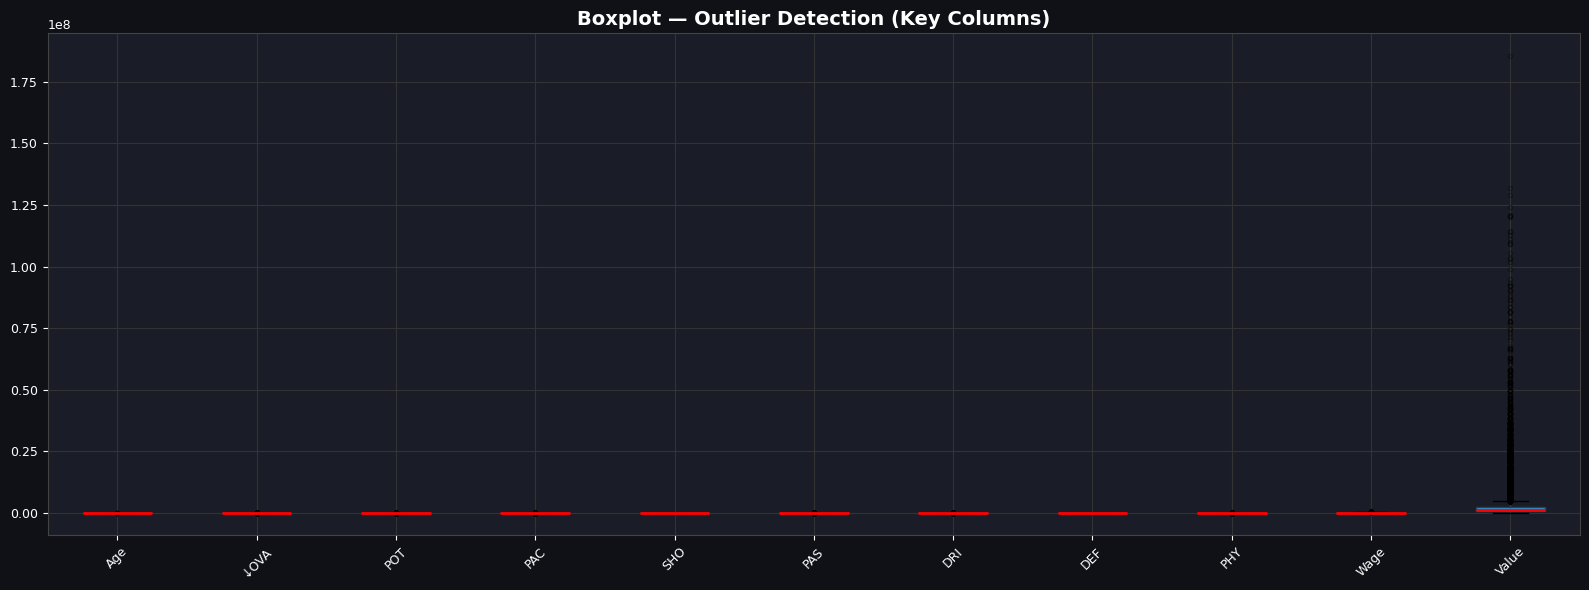


── 2. Z-SCORE METHOD (Threshold : |Z| > 3) ──

         Feature  Total  Outliers (Z>3)  Outlier %
     Goalkeeping  17920             635       3.54
  GK Positioning  17920             607       3.39
     GK Handling  17920             601       3.35
     GK Reflexes  17920             580       3.24
      GK Kicking  17920             574       3.20
       GK Diving  17920             565       3.15
           Value  17920             341       1.90
              IR  17920             330       1.84
            Wage  17920             329       1.84
  Release Clause  17920             315       1.76
            Hits  15531             310       2.00
             W/F  17920             275       1.53
             PAC  17920             183       1.02
              ID  17920             160       0.89
    Sprint Speed  17920             141       0.79
    Acceleration  17920             126       0.70
        Movement  17920             106       0.59
             DRI  17920           

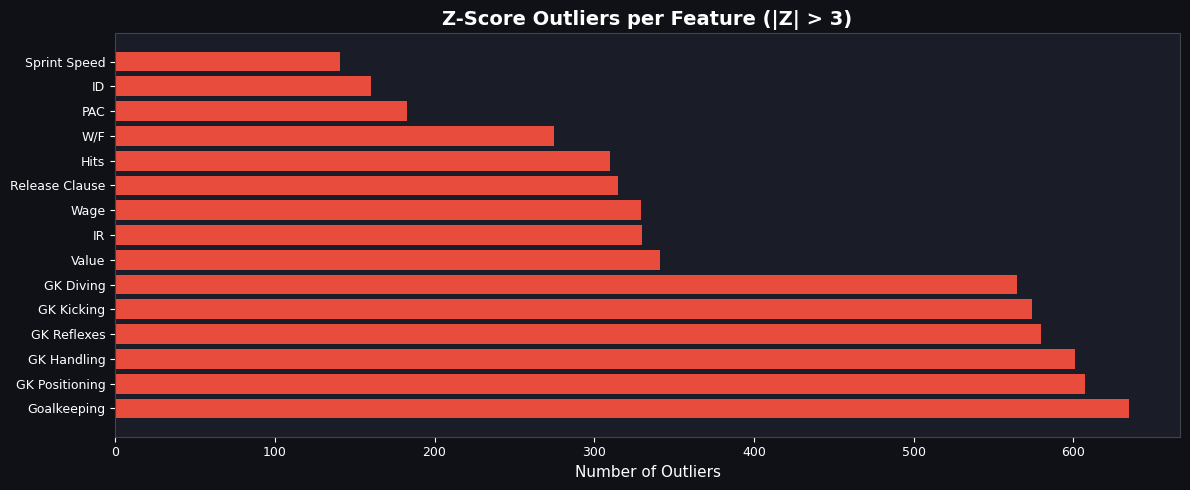


── 3. IQR METHOD ──

         Feature        Q1         Q3       IQR  Lower Bound  Upper Bound  Outliers  Outlier %
             W/F      3.00       3.00       0.0         3.00         3.00      6886      38.43
  Release Clause 432750.00 3000000.00 2567250.0  -3418125.00   6850875.00      2617      14.60
           Value 475000.00 2100000.00 1625000.0  -1962500.00   4537500.00      2162      12.06
            Hits      2.00      15.00      13.0       -17.50        34.50      2115      13.62
     Goalkeeping     48.00      60.00      12.0        30.00        78.00      2032      11.34
    Ball Control     55.00      69.00      14.0        34.00        90.00      2020      11.27
            Wage   1000.00    9000.00    8000.0    -11000.00     21000.00      1965      10.97
      GK Kicking      8.00      14.00       6.0        -1.00        23.00      1964      10.96
  GK Positioning      8.00      14.00       6.0        -1.00        23.00      1962      10.95
       GK Diving      8.00  

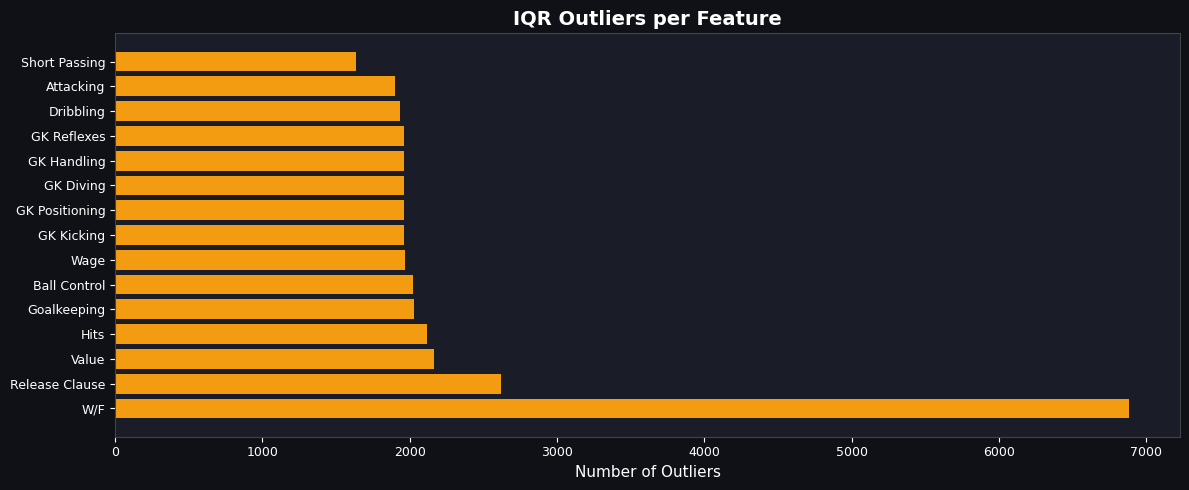


   COMBINED OUTLIER SUMMARY
         Feature  Z-Score Outliers  Z %  IQR Outliers  IQR %
             W/F               275 1.53          6886  38.43
  Release Clause               315 1.76          2617  14.60
           Value               341 1.90          2162  12.06
            Hits               310 2.00          2115  13.62
     Goalkeeping               635 3.54          2032  11.34
    Ball Control                 4 0.02          2020  11.27
            Wage               329 1.84          1965  10.97
      GK Kicking               574 3.20          1964  10.96
  GK Positioning               607 3.39          1962  10.95
     GK Handling               601 3.35          1961  10.94
       GK Diving               565 3.15          1961  10.94
     GK Reflexes               580 3.24          1961  10.94
       Dribbling                 0 0.00          1936  10.80
       Attacking                 0 0.00          1898  10.59
   Short Passing                92 0.51          1635   

In [47]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 60)
print("   OUTLIER DETECTION")
print("=" * 60)
print(f"  Numeric columns to analyse : {len(numeric_cols)}")

# ─────────────────────────────────────────────
# 1. BOXPLOTS
# ─────────────────────────────────────────────
print("\n── 1. BOXPLOTS ──")

# Plot key columns only (too many to plot all 77)
key_cols = ['Age', '↓OVA', 'POT', 'PAC', 'SHO', 'PAS',
            'DRI', 'DEF', 'PHY', 'Wage', 'Value']

plt.figure(figsize=(16, 6))
df[key_cols].boxplot(vert=True, patch_artist=True,
                     boxprops    = dict(facecolor='#3498db', color='#2c3e50'),
                     medianprops = dict(color='red',   linewidth=2),
                     whiskerprops= dict(color='#2c3e50'),
                     flierprops  = dict(marker='o', color='red',
                                        alpha=0.3, markersize=3))
plt.title('Boxplot — Outlier Detection (Key Columns)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 2. Z-SCORE METHOD
#    Threshold : |Z| > 3  → Outlier
# ─────────────────────────────────────────────
print("\n── 2. Z-SCORE METHOD (Threshold : |Z| > 3) ──\n")

zscore_results = []
for col in numeric_cols:
    col_data   = df[col].dropna()
    z_scores   = np.abs(stats.zscore(col_data))
    n_outliers = (z_scores > 3).sum()
    pct        = round((n_outliers / len(col_data)) * 100, 2)
    zscore_results.append([col, len(col_data), n_outliers, pct])

zscore_df = pd.DataFrame(zscore_results,
                         columns=['Feature','Total','Outliers (Z>3)','Outlier %'])
zscore_df = zscore_df.sort_values('Outliers (Z>3)', ascending=False).reset_index(drop=True)

print(zscore_df.to_string(index=False))

# Z-score bar chart
top_z = zscore_df[zscore_df['Outliers (Z>3)'] > 0].head(15)
plt.figure(figsize=(12, 5))
plt.barh(top_z['Feature'], top_z['Outliers (Z>3)'], color='#e74c3c')
plt.title('Z-Score Outliers per Feature (|Z| > 3)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outliers')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 3. IQR METHOD
#    Lower = Q1 - 1.5*IQR
#    Upper = Q3 + 1.5*IQR
# ─────────────────────────────────────────────
print("\n── 3. IQR METHOD ──\n")

iqr_results = []
for col in numeric_cols:
    col_data = df[col].dropna()
    Q1       = col_data.quantile(0.25)
    Q3       = col_data.quantile(0.75)
    IQR      = Q3 - Q1
    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = ((col_data < lower) | (col_data > upper)).sum()
    pct      = round((outliers / len(col_data)) * 100, 2)
    iqr_results.append([col, round(Q1,2), round(Q3,2),
                        round(IQR,2), round(lower,2),
                        round(upper,2), outliers, pct])

iqr_df = pd.DataFrame(iqr_results,
                      columns=['Feature','Q1','Q3','IQR',
                               'Lower Bound','Upper Bound',
                               'Outliers','Outlier %'])
iqr_df = iqr_df.sort_values('Outliers', ascending=False).reset_index(drop=True)

print(iqr_df.to_string(index=False))

# IQR bar chart
top_iqr = iqr_df[iqr_df['Outliers'] > 0].head(15)
plt.figure(figsize=(12, 5))
plt.barh(top_iqr['Feature'], top_iqr['Outliers'], color='#f39c12')
plt.title('IQR Outliers per Feature', fontsize=14, fontweight='bold')
plt.xlabel('Number of Outliers')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# 4. COMBINED SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("   COMBINED OUTLIER SUMMARY")
print("=" * 60)

summary = pd.merge(
    zscore_df[['Feature','Outliers (Z>3)','Outlier %']].rename(
        columns={'Outliers (Z>3)':'Z-Score Outliers','Outlier %':'Z %'}),
    iqr_df[['Feature','Outliers','Outlier %']].rename(
        columns={'Outliers':'IQR Outliers','Outlier %':'IQR %'}),
    on='Feature'
)
summary = summary.sort_values('IQR Outliers', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

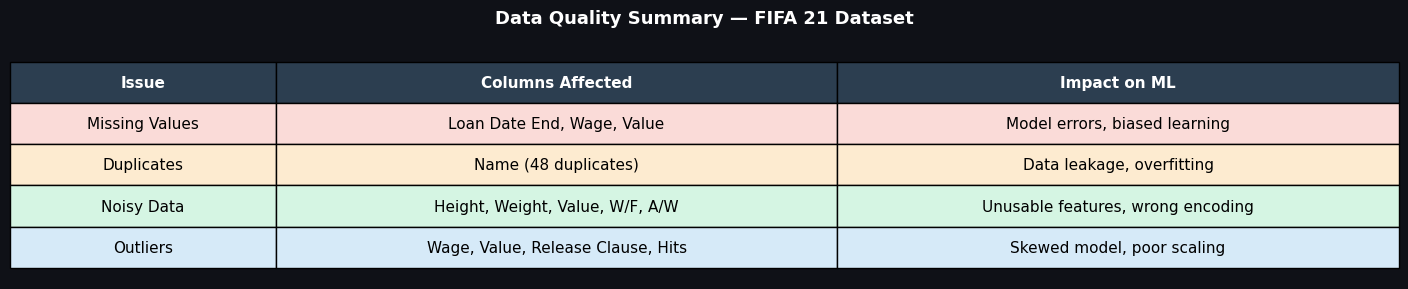

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Summary Table Data ────────────────────────────────────
data = {
    'Issue': [
        'Missing Values',
        'Duplicates',
        'Noisy Data',
        'Outliers'
    ],
    'Columns Affected': [
        'Loan Date End, Wage, Value',
        'Name (48 duplicates)',
        'Height, Weight, Value, W/F, A/W',
        'Wage, Value, Release Clause, Hits'
    ],
    'Impact on ML': [
        'Model errors, biased learning',
        'Data leakage, overfitting',
        'Unusable features, wrong encoding',
        'Skewed model, poor scaling'
    ]
}

df_summary = pd.DataFrame(data)

# ── Print as text table ───────────────────────────────────
# print(df_summary.to_string(index=False))

# ── Visualize as matplotlib table ────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText  = df_summary.values,
    colLabels = df_summary.columns,
    cellLoc   = 'center',
    loc       = 'center',
    colWidths = [0.18, 0.38, 0.38]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

# ── Header row styling ────────────────────────────────────
for col in range(3):
    table[0, col].set_facecolor('#2c3e50')
    table[0, col].set_text_props(color='white', fontweight='bold')

# ── Row colors ────────────────────────────────────────────
row_colors = ['#FADBD8', '#FDEBD0', '#D5F5E3', '#D6EAF8']

for row in range(1, 5):
    for col in range(3):
        table[row, col].set_facecolor(row_colors[row - 1])
        table[row, col].set_text_props(color='black') # Set text color for rows

plt.title('Data Quality Summary — FIFA 21 Dataset',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

**1. Missing Values**
- Columns like `Loan Date End`, `Wage`, and `Value` contain missing entries
- ML algorithms like Linear Regression cannot handle `NaN` and will crash during training
- Missing values in key columns cause biased learning toward high-profile players only
- Removing rows with missing data reduces the dataset below 18,979 records
- Statistical measures like mean and std silently skip `NaN`, giving misleading EDA results

---

**2. Duplicate Records**
- 48 players appear more than once with different column values
- Same player in both train and test sets causes data leakage, inflating accuracy
- Duplicate rows distort statistics — Messi appearing twice doubles his influence on mean OVA
- Model overfits to specific players instead of learning general patterns

---

**3. Noisy Data**
- Columns like `Height` (170cm), `Value` (€103.5M), `W/F` (4★) are stored as strings — unusable in ML directly
- Invalid entries like `Height = abc` or `Rating = -5` break model training entirely
- Inconsistent labels like `"left"`, `"Left"`, `"LEFT"` are treated as 3 separate categories after encoding
- Out-of-range values like `Age = 200` force the model to fit impossible data points

---

**4. Outliers**
- Columns like `Wage`, `Value`, `Release Clause`, and `Hits` contain extreme values
- Elite players like Messi pull the mean far above what is typical for most players
- Linear Regression shifts toward outlier values, producing poor predictions for average players
- Extreme values compress all others toward zero during normalisation, losing meaningful variation
- IQR detected more outliers than Z-score for skewed columns — method choice matters

Task C - Data Cleaning

In [49]:
import pandas as pd
import numpy as np

print("=" * 65)
print("   DATA PREPROCESSING & CLEANING")
print("=" * 65)
print(f"\n  Shape BEFORE : {df.shape}")

# ═════════════════════════════════════════════════════════
# STEP 1 : HANDLING MISSING VALUES
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 1 : HANDLING MISSING VALUES")
print("=" * 65)

# ── Before ────────────────────────────────────────────────
print(f"\n  Missing values BEFORE:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

# ── 1a. Drop columns with too many missing values (>50%) ──
threshold = 0.5
cols_to_drop = [col for col in df.columns
                if df[col].isnull().mean() > threshold]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\n  Columns dropped (>50% missing) : {cols_to_drop}")
print(f"  Justification : These columns have too many missing")
print(f"  values to impute reliably. Keeping them would")
print(f"  introduce more noise than information.")

# ── 1b. Drop rows where target (OVA) is missing ───────────
before = df.shape[0]
df.dropna(subset=['↓OVA'], inplace=True)
print(f"\n  Rows dropped (missing OVA) : {before - df.shape[0]}")
print(f"  Justification : Target variable cannot be imputed.")
print(f"  A row without a target is useless for training.")

# ── 1c. Numeric columns → Median imputation ───────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"\n  [{col}] → Median imputation ({missing} values filled with {median_val})")
        print(f"  Justification : Median is robust to outliers.")
        print(f"  Wage & Value are skewed — median is better than mean.")

# ── 1d. Categorical columns → Mode imputation ─────────────
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"\n  [{col}] → Mode imputation ({missing} values filled with '{mode_val}')")
        print(f"  Justification : Most frequent value is the best")
        print(f"  guess for categorical columns like Club or Position.")

print(f"\n  Missing values AFTER : {df.isnull().sum().sum()}")

# ═════════════════════════════════════════════════════════
# STEP 2 : FIXING INCONSISTENT DATA
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 2 : FIXING INCONSISTENT DATA")
print("=" * 65)

# ── 2a. Convert Height → numeric (170cm → 170) ────────────
df['Height'] = pd.to_numeric(
    df['Height'].astype(str).str.replace('cm','').str.strip(),
    errors='coerce')
print(f"\n  Height converted to numeric sample: {df['Height'].head(3).tolist()}")

# ── 2b. Convert Weight → numeric (72kg → 72) ─────────────
df['Weight'] = pd.to_numeric(
    df['Weight'].astype(str).str.replace('kg','').str.strip(),
    errors='coerce')
print(f"  Weight converted to numeric sample: {df['Weight'].head(3).tolist()}")

# ── 2c. Convert Value / Wage / Release Clause ─────────────
def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

for col in ['Value', 'Wage', 'Release Clause']:
    if col in df.columns:
        df[col] = df[col].apply(parse_currency)
        print(f"  {col} converted to numeric   sample: {df[col].head(3).tolist()}")

# ── 2d. Convert W/F, SM, IR → numeric (4★ → 4) ───────────
for col in ['W/F', 'SM', 'IR']:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace('★','').str.strip(),
            errors='coerce')
print(f"  W/F, SM, IR converted to numeric ")

# ── 2e. Standardise categorical labels ────────────────────
print(f"\n  Standardising categorical labels:")

# Preferred Foot
print(f"  Preferred Foot before : {df['Preferred Foot'].unique()}")
df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()
print(f"  Preferred Foot after  : {df['Preferred Foot'].unique()}")

# A/W and D/W
for col in ['A/W', 'D/W']:
    if col in df.columns:
        print(f"  {col} before : {df[col].unique()}")
        df[col] = df[col].str.strip().str.title()
        print(f"  {col} after  : {df[col].unique()}")

# Best Position
df['Best Position'] = df['Best Position'].str.strip().str.upper()
print(f"  Best Position standardised ({df['Best Position'].nunique()} unique values)")

# Nationality
df['Nationality'] = df['Nationality'].str.strip().str.title()
print(f"  Nationality standardised  ({df['Nationality'].nunique()} unique values)")

# ── 2f. Remove impossible values ──────────────────────────
print(f"\n  Removing impossible values:")

# Ratings must be 0–100
rating_cols = ['↓OVA','POT','BOV','Crossing','Finishing',
               'Heading Accuracy','Short Passing','Volleys',
               'Dribbling','Curve','FK Accuracy','Long Passing',
               'Ball Control','Acceleration','Sprint Speed',
               'Agility','Reactions','Balance','Shot Power',
               'Jumping','Stamina','Strength','Long Shots',
               'Aggression','Interceptions','Positioning',
               'Vision','Penalties','Composure','Marking',
               'Standing Tackle','Sliding Tackle',
               'GK Diving','GK Handling','GK Kicking',
               'GK Positioning','GK Reflexes',
               'PAC','SHO','PAS','DRI','DEF','PHY']

for col in rating_cols:
    if col in df.columns:
        out = ((df[col] < 0) | (df[col] > 100)).sum()
        if out > 0:
            df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan
            print(f"   {col} : {out} impossible values removed")

# Age 15–50
out_age = ((df['Age'] < 15) | (df['Age'] > 50)).sum()
df.loc[(df['Age'] < 15) | (df['Age'] > 50), 'Age'] = np.nan
print(f"  Age  : {out_age} impossible values removed (outside 15–50)")

# Height 140–220 cm
out_h = ((df['Height'] < 140) | (df['Height'] > 220)).sum()
df.loc[(df['Height'] < 140) | (df['Height'] > 220), 'Height'] = np.nan
print(f"  Height : {out_h} impossible values removed (outside 140–220 cm)")

# Weight 40–120 kg
out_w = ((df['Weight'] < 40) | (df['Weight'] > 120)).sum()
df.loc[(df['Weight'] < 40) | (df['Weight'] > 120), 'Weight'] = np.nan
print(f"  Weight : {out_w} impossible values removed (outside 40–120 kg)")

print(f"\n  All impossible values replaced with NaN")

# ═════════════════════════════════════════════════════════
# STEP 3 : REMOVING DUPLICATES
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 3 : REMOVING DUPLICATES")
print("=" * 65)

print(f"\n  Shape before duplicate removal : {df.shape}")

# Full row duplicates
full_dups = df.duplicated().sum()
print(f"\n  Full duplicate rows detected   : {full_dups}")
df = df.drop_duplicates()
print(f"  Full duplicate rows removed    : {full_dups}")

# Duplicate Names — keep highest OVA
name_dups = df.duplicated(subset=['Name']).sum()
print(f"\n  Duplicate Names detected       : {name_dups}")
df = df.sort_values('↓OVA', ascending=False) \
       .drop_duplicates(subset=['Name'], keep='first') \
       .reset_index(drop=True)
print(f"  Duplicate Names removed        : {name_dups}")
print(f"  Strategy : Kept row with highest OVA for each player")

# Duplicate LongNames
long_dups = df.duplicated(subset=['LongName']).sum()
print(f"\n  Duplicate LongNames detected   : {long_dups}")
df = df.drop_duplicates(subset=['LongName'], keep='first') \
       .reset_index(drop=True)
print(f"  Duplicate LongNames removed    : {long_dups}")

print(f"\n  Shape after duplicate removal  : {df.shape}")
print(f"  Total rows removed             : {18979 - df.shape[0]}")

# ── Final Summary ─────────────────────────────────────────
print("\n" + "=" * 65)
print("   FINAL PREPROCESSING SUMMARY")
print("=" * 65)
print(f"""
  Step 1 — Missing Values
    • Dropped columns with >50% missing       : {len(cols_to_drop)}
    • Numeric columns → Median imputation
    • Categorical columns → Mode imputation
    • Remaining missing values               : {df.isnull().sum().sum()}

  Step 2 — Inconsistent Data
    • Height, Weight converted to numeric
    • Value, Wage, Release Clause parsed to float
    • W/F, SM, IR star ratings → integer
    • Preferred Foot, A/W, D/W standardised
    • Impossible values replaced with NaN

  Step 3 — Duplicates
    • Full duplicate rows removed            : {full_dups}
    • Duplicate Names removed                : {name_dups}
    • Duplicate LongNames removed            : {long_dups}

  Original shape  : (18979, 77)
  Final shape     : {df.shape}
""")

   DATA PREPROCESSING & CLEANING

  Shape BEFORE : (17920, 77)

   STEP 1 : HANDLING MISSING VALUES

  Missing values BEFORE:
Age                  1
Height              40
Weight              40
Loan Date End    16961
Hits              2389

  Columns dropped (>50% missing) : ['Loan Date End']
  Justification : These columns have too many missing
  values to impute reliably. Keeping them would
  introduce more noise than information.

  Rows dropped (missing OVA) : 0
  Justification : Target variable cannot be imputed.
  A row without a target is useless for training.

  [Age] → Median imputation (1 values filled with 25.0)
  Justification : Median is robust to outliers.
  Wage & Value are skewed — median is better than mean.

  [Height] → Median imputation (40 values filled with 181.0)
  Justification : Median is robust to outliers.
  Wage & Value are skewed — median is better than mean.

  [Weight] → Median imputation (40 values filled with 75.0)
  Justification : Median is robust to

Justification for each method chosen:

**1. Drop Columns (>50% missing) — e.g. Loan Date End**

More than half the data is missing, meaning there is not enough information to impute reliably
Any imputed value would be a guess for the majority of rows, introducing more noise than signal
Keeping such a column would mislead the model rather than help it learn real patterns


**2. Drop Rows (missing ↓OVA — Target Variable)**

The target variable is what the model is trying to predict
A row without a target value has no use during supervised learning — it cannot contribute to training or evaluation
Imputing the target would mean the model is partially predicting values it invented itself, which is invalid


**3. Median Imputation — Numeric columns (Wage, Value, Release Clause, Height, Weight)**

These columns are heavily right-skewed due to elite players like Messi and Ronaldo having extreme values
Mean imputation would be pulled upward by those outliers, giving an unrealistic fill value for average players
Median is the middle value of the distribution and is completely unaffected by extreme values, making it the safest and most representative choice for skewed numeric columns


**4. Mode Imputation — Categorical columns (Club, Positions, Best Position, Preferred Foot)**

Categorical columns have no numeric average or median — mean and median simply do not apply
The mode is the most frequently occurring category, making it the most statistically reasonable guess for a missing label
For example, if Preferred Foot is missing, filling with Right (the mode) is correct since the majority of players are right-footed


**5. Removing Impossible Values — Rating columns, Age, Height, Weight**

Values like OVA = 150, Age = 200, or Height = 5 are physically and logically impossible in football
Keeping them would force the model to try to fit data points that cannot exist in reality, pulling predictions in the wrong direction
Replacing with NaN and then imputing is safer than keeping a value that is guaranteed to be wrong

Task D - Data Transformation

In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler



# ═════════════════════════════════════════════════════════
# STEP 1 : ENCODING CATEGORICAL VARIABLES
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 1 : ENCODING CATEGORICAL VARIABLES")
print("=" * 65)

# ── 1a. Label Encoding ────────────────────────────────────
# Used for : Preferred Foot, A/W, D/W
# Reason   : Binary or ordinal columns with 2–3 categories.
#            Label encoding is sufficient and avoids
#            unnecessary extra columns.

print("\n  1a. LABEL ENCODING")
print("      Applied to : Preferred Foot, A/W, D/W")
print("      Reason     : Low cardinality (2-3 categories),")
print("                   ordinal nature, avoids extra columns\n")

le = LabelEncoder()

label_cols = ['Preferred Foot', 'A/W', 'D/W']
for col in label_cols:
    original = df[col].unique()
    df[col]  = le.fit_transform(df[col].astype(str))
    encoded  = df[col].unique()
    print(f"  {col}")
    print(f"    Before : {original}")
    print(f"    After  : {encoded}\n")

# ── 1b. One-Hot Encoding ──────────────────────────────────
# Used for : Best Position, Nationality
# Reason   : Nominal columns with no order.
#            Label encoding would imply GK > ST which is
#            wrong. One-Hot creates a binary column per
#            category so no false order is implied.

print("\n  1b. ONE-HOT ENCODING")
print("      Applied to : Best Position, Nationality")
print("      Reason     : Nominal — no natural order exists.")
print("                   One-Hot avoids implying false rank\n")

before_cols = df.shape[1]

# Check if 'Best Position' exists before one-hot encoding
if 'Best Position' in df.columns:
    df = pd.get_dummies(df, columns=['Best Position'], prefix='POS')
else:
    print("  'Best Position' column not found for one-hot encoding, skipping.")

# Check if 'Nationality' exists before one-hot encoding
if 'Nationality' in df.columns:
    df = pd.get_dummies(df, columns=['Nationality'],   prefix='NAT')
else:
    print("  'Nationality' column not found for one-hot encoding, skipping.")

after_cols = df.shape[1]
print(f"  Columns BEFORE One-Hot : {before_cols}")
print(f"  Columns AFTER  One-Hot : {after_cols}")
print(f"  New columns created    : {after_cols - before_cols}")

# ═════════════════════════════════════════════════════════
# STEP 2 : FEATURE SCALING
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 2 : FEATURE SCALING")
print("=" * 65)

print("""
  Why scaling is necessary:
  • Features like Wage (€560,000) and Age (33) are on
    completely different scales
  • ML algorithms like KNN and SVM use distance calculations
    — unscaled features with larger ranges dominate unfairly
  • Gradient descent converges faster with scaled features
  • Tree-based models (Random Forest) do NOT need scaling
    but regression and distance-based models do
""")

# Columns to scale
scale_cols = ['Age', 'Height', 'Weight', 'Wage', 'Value',
              'Release Clause', 'PAC', 'SHO', 'PAS',
              'DRI', 'DEF', 'PHY', '↓OVA', 'POT',
              'Total Stats', 'Base Stats']

scale_cols = [col for col in scale_cols if col in df.columns]

# ── 2a. Min-Max Normalization ─────────────────────────────
# Used for : PAC, SHO, PAS, DRI, DEF, PHY (already 0–100)
# Reason   : Scales to 0–1 range. Good when data has
#            known fixed boundaries (ratings are 0–100).
#            Preserves relative differences between players.

minmax_cols = ['PAC','SHO','PAS','DRI','DEF','PHY',
               '↓OVA','POT','Total Stats','Base Stats']
minmax_cols = [col for col in minmax_cols if col in df.columns]

scaler_mm   = MinMaxScaler()
df_minmax   = df[minmax_cols].copy()
df[minmax_cols] = scaler_mm.fit_transform(df[minmax_cols])

print("  2a. MIN-MAX NORMALIZATION (scale to 0–1)")
print("      Applied to : Rating columns (PAC, SHO, PAS, DRI, DEF, PHY, OVA)")
print("      Reason     : Ratings already have fixed bounds (0–100).")
print("                   Min-Max preserves relative player differences\n")

summary_mm = pd.DataFrame({
    'Feature' : minmax_cols,
    'Min Before' : [0]*len(minmax_cols),
    'Max Before' : [100]*len(minmax_cols),
    'Min After'  : df[minmax_cols].min().round(4).values,
    'Max After'  : df[minmax_cols].max().round(4).values
})
print(summary_mm.to_string(index=False))

# ── 2b. Standardization (Z-score) ────────────────────────
# Used for : Wage, Value, Release Clause, Height, Weight
# Reason   : These columns are skewed with extreme outliers.
#            Z-score centres data at mean=0, std=1.
#            More robust than Min-Max when outliers exist.

std_cols = ['Age','Height','Weight','Wage','Value','Release Clause']
std_cols = [col for col in std_cols if col in df.columns]

scaler_std   = StandardScaler()
df[std_cols] = scaler_std.fit_transform(df[std_cols])

print("\n\n  2b. STANDARDIZATION / Z-SCORE (mean=0, std=1)")
print("      Applied to : Wage, Value, Height, Weight, Age")
print("      Reason     : Skewed columns with outliers.")
print("                   Z-score handles extreme values better\n")

summary_std = pd.DataFrame({
    'Feature'    : std_cols,
    'Mean After' : df[std_cols].mean().round(4).values,
    'Std After'  : df[std_cols].std().round(4).values,
    'Min After'  : df[std_cols].min().round(4).values,
    'Max After'  : df[std_cols].max().round(4).values
})
print(summary_std.to_string(index=False))



# ═════════════════════════════════════════════════════════
# STEP 3 : FEATURE ENGINEERING
# ═════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("   STEP 3 : FEATURE ENGINEERING")
print("=" * 65)

# Re-load raw numeric values for feature engineering
df_raw = pd.read_csv('/content/fifa21 datatset.csv', low_memory=False)
for col in ['Height','Weight']:
    df_raw[col] = pd.to_numeric(
        df_raw[col].astype(str).str.replace('cm','').str.replace('kg','').str.strip(),
        errors='coerce')
for col in ['Value','Wage','Release Clause']:
    df_raw[col] = df_raw[col].apply(parse_currency)
for col in ['W/F','SM','IR']:
    df_raw[col] = pd.to_numeric(
        df_raw[col].astype(str).str.replace('★','').str.strip(), errors='coerce')

numeric_cols_raw = df_raw.select_dtypes(include=[np.number]).columns
df_raw[numeric_cols_raw] = df_raw[numeric_cols_raw].fillna(df_raw[numeric_cols_raw].median())

# ── 3a. OVA Gap (Potential - Overall) ────────────────────
# Reason : Shows how much room a player has to grow.
#          A young player with high gap = high future value.
df_raw['OVA_Gap'] = df_raw['POT'] - df_raw['↓OVA']
print("\n  3a. OVA_Gap = POT - OVA")
print("      Reason : Measures growth potential.")
print("               High gap = player still has room to improve")
print(f"      Sample : {df_raw['OVA_Gap'].head(5).tolist()}\n")

# ── 3b. BMI (Body Mass Index) ─────────────────────────────
# Reason : Physical condition indicator. Combines Height
#          and Weight into one meaningful feature.
df_raw['BMI'] = df_raw['Weight'] / ((df_raw['Height'] / 100) ** 2)
print("  3b. BMI = Weight / (Height/100)^2")
print("      Reason : Combines Height & Weight into one feature.")
print("               Indicates physical build of player")
print(f"      Sample : {df_raw['BMI'].round(2).head(5).tolist()}\n")

# ── 3c. Attacking Score ───────────────────────────────────
# Reason : Single composite score for attacking ability.
#          Combines Finishing, Dribbling, Shot Power, Volleys.
df_raw['Attacking_Score'] = (df_raw['Finishing']  +
                              df_raw['Dribbling']  +
                              df_raw['Shot Power'] +
                              df_raw['Volleys'])    / 4
print("  3c. Attacking_Score = mean(Finishing, Dribbling, Shot Power, Volleys)")
print("      Reason : Summarises attacking ability in one feature.")
print("               Reduces dimensionality without losing info")
print(f"      Sample : {df_raw['Attacking_Score'].round(2).head(5).tolist()}\n")

# ── 3d. Defending Score ───────────────────────────────────
df_raw['Defending_Score'] = (df_raw['Marking']         +
                              df_raw['Standing Tackle'] +
                              df_raw['Sliding Tackle']) / 3
print("  3d. Defending_Score = mean(Marking, Standing Tackle, Sliding Tackle)")
print("      Reason : Single score for defensive ability.")
print("               Useful for position-based player analysis")
print(f"      Sample : {df_raw['Defending_Score'].round(2).head(5).tolist()}\n")

# ── 3e. Physical Score ────────────────────────────────────
df_raw['Physical_Score'] = (df_raw['Strength'] +
                             df_raw['Stamina']  +
                             df_raw['Jumping']) / 3
print("  3e. Physical_Score = mean(Strength, Stamina, Jumping)")
print("      Reason : Captures overall physical condition.")
print("               Relevant for predicting player endurance")
print(f"      Sample : {df_raw['Physical_Score'].round(2).head(5).tolist()}\n")

# ── 3f. Value per OVA ─────────────────────────────────────
# Reason : Shows cost-efficiency. Low ratio = undervalued
#          player. Useful for player scouting analysis.
df_raw['Value_per_OVA'] = df_raw['Value'] / df_raw['↓OVA']
print("  3f. Value_per_OVA = Value / OVA")
print("      Reason : Measures cost-efficiency of a player.")
print("               Low ratio = undervalued / bargain player")
print(f"      Sample : {df_raw['Value_per_OVA'].round(2).head(5).tolist()}\n")

# ── 3g. Is_Young_Talent ───────────────────────────────────
# Reason : Binary flag for players aged under 23 with
#          high potential (POT >= 80). Useful for scouting.
df_raw['Is_Young_Talent'] = ((df_raw['Age'] < 23) & (df_raw['POT'] >= 80)).astype(int)
print("  3g. Is_Young_Talent = (Age < 23) AND (POT >= 80)")
print("      Reason : Flags young high-potential players.")
print("               Directly useful for scouting models")
print(f"      Sample : {df_raw['Is_Young_Talent'].head(5).tolist()}\n")

# ── Show new features summary ─────────────────────────────
new_features = ['OVA_Gap','BMI','Attacking_Score',
                'Defending_Score','Physical_Score',
                'Value_per_OVA','Is_Young_Talent']

print("\n  New Features Summary:")
print(df_raw[new_features].describe().round(2).to_string())

# ── Final Summary ─────────────────────────────────────────

print(f"""
  Step 1 — Encoding
    • Label Encoding  : Preferred Foot, A/W, D/W
    • One-Hot Encoding: Best Position, Nationality

  Step 2 — Scaling
    • Min-Max (0–1)   : Rating columns (PAC,SHO,PAS,DRI,DEF,PHY)
    • Z-score         : Wage, Value, Height, Weight, Age

  Step 3 — Feature Engineering
    • OVA_Gap         : Growth potential (POT - OVA)
    • BMI             : Physical build indicator
    • Attacking_Score : Composite attacking ability
    • Defending_Score : Composite defending ability
    • Physical_Score  : Composite physical condition
    • Value_per_OVA   : Cost efficiency / player value
    • Is_Young_Talent : Binary scouting flag (Age<23, POT>=80)
""")




   STEP 1 : ENCODING CATEGORICAL VARIABLES

  1a. LABEL ENCODING
      Applied to : Preferred Foot, A/W, D/W
      Reason     : Low cardinality (2-3 categories),
                   ordinal nature, avoids extra columns

  Preferred Foot
    Before : [0 1]
    After  : [0 1]

  A/W
    Before : [2 0 1]
    After  : [2 0 1]

  D/W
    Before : [1 2 0]
    After  : [1 2 0]


  1b. ONE-HOT ENCODING
      Applied to : Best Position, Nationality
      Reason     : Nominal — no natural order exists.
                   One-Hot avoids implying false rank

  'Best Position' column not found for one-hot encoding, skipping.
  'Nationality' column not found for one-hot encoding, skipping.
  Columns BEFORE One-Hot : 251
  Columns AFTER  One-Hot : 251
  New columns created    : 0

   STEP 2 : FEATURE SCALING

  Why scaling is necessary:
  • Features like Wage (€560,000) and Age (33) are on
    completely different scales
  • ML algorithms like KNN and SVM use distance calculations
    — unscaled feat

Why Scaling is Necessary

*   Features in this dataset exist on vastly different scales — Wage can be €560,000 while Age is just 33. Without scaling, algorithms like KNN, SVM, and Linear Regression treat Wage as more important simply because its numbers are larger, not because it actually is more important. Scaling brings all features to the same range so every feature contributes equally to the model.
*   Gradient descent-based algorithms like Linear Regression converge much faster when features are scaled. Unscaled features create an uneven loss surface causing the algorithm to zigzag slowly, while scaled features create a smooth and uniform surface allowing the model to reach the optimal solution in fewer iterations.


Which Encoding Was Used and Why

*   Label Encoding was applied to Preferred Foot, A/W, and D/W because these columns have only 2–3 categories with a natural order — for example Low → Medium → High for work rate. Label encoding simply assigns a number to each category (0, 1, 2) which is compact, efficient, and does not create unnecessary extra columns.
*   One-Hot Encoding was applied to Best Position and Nationality because these are nominal columns with no natural order — there is no sense in which GK = 1 is less than ST = 2. Assigning numbers would imply a false ranking between positions. One-Hot instead creates a separate binary column for each category, ensuring the model treats all positions and nationalities as completely independent of one another.

Reasoning Behind New Features



*   Existing raw features like Height, Weight, Finishing, and Dribbling each capture only one aspect of a player. New features like BMI, Attacking_Score, and Defending_Score combine related attributes into a single meaningful measure, reducing the number of input features while preserving the overall information — making it easier for the model to learn patterns.

*   Features like OVA_Gap (POT - OVA), Value_per_OVA, and Is_Young_Talent capture relationships between existing columns that the model cannot discover on its own. For example, a player with low Value but high OVA is clearly undervalued — but the model only sees this if we explicitly create a Value_per_OVA feature to highlight it.














In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

drop_cols = ['ID','Name','LongName','photoUrl','playerUrl',
             'Club','Joined','Loan Date End','Contract','Positions']
# Only drop columns that are actually present in the DataFrame to avoid errors
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)


# ─────────────────────────────────────────────
# STEP 1 : SEPARATE FEATURES AND TARGET
# ─────────────────────────────────────────────
print("\n── STEP 1 : SEPARATE FEATURES AND TARGET ──\n")

target   = '↓OVA'
X        = df.drop(columns=[target]) # Remove the target variable from features
y        = df[target] # Assign the target variable

print(f"  Target Variable      : {target}")
print(f"  Feature matrix X     : {X.shape}  (rows x features)")
print(f"  Target vector  y     : {y.shape}  (rows)")
print(f"\n  Sample target values (y) :")
print(f"  {y.head(10).tolist()}")
print(f"\n  Sample feature columns (X) :")
print(f"  {X.columns[:10].tolist()}")

# ─────────────────────────────────────────────
# STEP 2 : SPLIT INTO TRAIN AND TEST SETS
# ─────────────────────────────────────────────
print("\n── STEP 2 : TRAIN / TEST SPLIT (80% / 20%) ──\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42
)

print(f"  Total Records        : {len(df)}")
print(f"  Training Set  (80%)  : {X_train.shape[0]} records")
print(f"  Testing  Set  (20%)  : {X_test.shape[0]} records")

# ─────────────────────────────────────────────
# STEP 3 : VERIFY THE SPLIT
# ─────────────────────────────────────────────
print("\n── STEP 3 : VERIFICATION ──\n")

print(f"  X_train shape        : {X_train.shape}")
print(f"  X_test  shape        : {X_test.shape}")
print(f"  y_train shape        : {y_train.shape}")
print(f"  y_test  shape        : {y_test.shape}")

print(f"\n  Target Distribution FULL DATASET :")
print(f"    Mean   : {y.mean():.2f}")
print(f"    Std    : {y.std():.2f}")
print(f"    Min    : {y.min()}")
print(f"    Max    : {y.max()}")

print(f"\n  Target Distribution TRAIN SET :")
print(f"    Mean   : {y_train.mean():.2f}")
print(f"    Std    : {y_train.std():.2f}")
print(f"    Min   : {y_train.min()}")
print(f"    Max   : {y_train.max()}")

print(f"\n  Target Distribution TEST SET :")
print(f"    Mean   : {y_test.mean():.2f}")
print(f"    Std    : {y_test.std():.2f}")
print(f"    Min   : {y_test.min()}")
print(f"    Max   : {y_test.max()}")


── STEP 1 : SEPARATE FEATURES AND TARGET ──

  Target Variable      : ↓OVA
  Feature matrix X     : (18979, 248)  (rows x features)
  Target vector  y     : (18979,)  (rows)

  Sample target values (y) :
  [93, 92, 91, 91, 91, 91, 90, 90, 90, 90]

  Sample feature columns (X) :
  ['Age', 'POT', 'Height', 'Weight', 'BOV', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing']

── STEP 2 : TRAIN / TEST SPLIT (80% / 20%) ──

  Total Records        : 18979
  Training Set  (80%)  : 15183 records
  Testing  Set  (20%)  : 3796 records

── STEP 3 : VERIFICATION ──

  X_train shape        : (15183, 248)
  X_test  shape        : (3796, 248)
  y_train shape        : (15183,)
  y_test  shape        : (3796,)

  Target Distribution FULL DATASET :
    Mean   : 65.72
    Std    : 6.97
    Min    : 47
    Max    : 93

  Target Distribution TRAIN SET :
    Mean   : 65.71
    Std    : 7.00
    Min   : 47
    Max   : 92

  Target Distribution TEST SET :
    Mean   : 65.76
    Std    : 6.85
    Min 

Why Train-Test Split is Necessary

*   Without a split, the model is trained and evaluated on the same data, which gives misleadingly high accuracy — the model simply memorises the training data rather than learning general patterns. This is called overfitting. The test set acts as unseen data that honestly measures whether the model has truly learned or just memorised.
*   The train-test split simulates real-world performance. In production, the model will always receive new unseen player data. Evaluating on the 20% test set replicates this scenario and gives a reliable and unbiased estimate of how well the model will actually perform when deployed on brand new data.




Task F - Final Clean Dataset

In [69]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split


# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# ── Pre-cleaning (Original parsing from string to numeric) ──────────────────────────
if 'Height' in df.columns:
    df['Height'] = pd.to_numeric(df['Height'].astype(str).str.replace('cm','').str.strip(), errors='coerce')
else:
    print("Warning: 'Height' column not found.")
if 'Weight' in df.columns:
    df['Weight'] = pd.to_numeric(df['Weight'].astype(str).str.replace('kg','').str.strip(), errors='coerce')
else:
    print("Warning: 'Weight' column not found.")

def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

for col in ['Value','Wage','Release Clause']:
    if col in df.columns:
        df[col] = df[col].apply(parse_currency)
    else:
        print(f"Warning: '{col}' column not found for currency parsing.")

for col in ['W/F','SM','IR']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace('★','').str.strip(), errors='coerce')
    else:
        print(f"Warning: '{col}' column not found for star rating parsing.")


# Standardise categoricals
if 'Preferred Foot' in df.columns:
    df['Preferred Foot'] = df['Preferred Foot'].str.strip().str.title()
else:
    print("Warning: 'Preferred Foot' column not found for standardization.")

if 'A/W' in df.columns:
    df['A/W']            = df['A/W'].str.strip().str.title()
else:
    print("Warning: 'A/W' column not found for standardization.")

if 'D/W' in df.columns:
    df['D/W']            = df['D/W'].str.strip().str.title()
else:
    print("Warning: 'D/W' column not found for standardization.")

if 'Best Position' in df.columns:
    df['Best Position']  = df['Best Position'].str.strip().str.upper()
else:
    print("Warning: 'Best Position' column not found for standardization.")

if 'Nationality' in df.columns:
    df['Nationality']    = df['Nationality'].str.strip().str.title()
else:
    print("Warning: 'Nationality' column not found for standardization.")

# Remove duplicates
df = df.drop_duplicates()
df = df.sort_values('↓OVA', ascending=False).drop_duplicates(subset=['Name'], keep='first').reset_index(drop=True)

# Drop columns with too many missing values (>50%) before imputation
# As identified in previous analysis, 'Loan Date End' has >90% missing values
initial_drop_cols = ['Loan Date End']
df.drop(columns=[c for c in initial_drop_cols if c in df.columns], inplace=True)

# Fill missing (after dropping columns with high missing percentage)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols_to_impute = [col for col in numeric_cols if col in df.columns and df[col].isnull().any()]
if len(numeric_cols_to_impute) > 0:
    for col in numeric_cols_to_impute:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
else:
    print("No numeric columns with missing values found for imputation.")


cat_cols = df.select_dtypes(include='object').columns
cat_cols_to_impute = [col for col in cat_cols if col in df.columns and df[col].isnull().any()]
for col in cat_cols_to_impute:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
if not cat_cols_to_impute:
    print("No categorical columns with missing values found for imputation.")


# Feature Engineering
# Ensure columns exist before creating new features
if all(col in df.columns for col in ['POT', '↓OVA']):
    df['OVA_Gap'] = df['POT'] - df['↓OVA']
else:
    print("Warning: Missing 'POT' or '↓OVA' for 'OVA_Gap' feature engineering. 'OVA_Gap' not created.")

if all(col in df.columns for col in ['Weight', 'Height']):
    df['BMI'] = df['Weight'] / ((df['Height'] / 100) ** 2)
else:
    print("Warning: Missing 'Weight' or 'Height' for 'BMI' feature engineering. 'BMI' not created.")

if all(col in df.columns for col in ['Finishing', 'Dribbling', 'Shot Power', 'Volleys']):
    df['Attacking_Score'] = (df['Finishing']  + df['Dribbling']  + df['Shot Power'] + df['Volleys'])    / 4
else:
    print("Warning: Missing attacking stats for 'Attacking_Score' feature engineering. 'Attacking_Score' not created.")

if all(col in df.columns for col in ['Marking', 'Standing Tackle', 'Sliding Tackle']):
    df['Defending_Score'] = (df['Marking']          + df['Standing Tackle'] + df['Sliding Tackle']) / 3
else:
    print("Warning: Missing defending stats for 'Defending_Score' feature engineering. 'Defending_Score' not created.")

if all(col in df.columns for col in ['Strength', 'Stamina', 'Jumping']):
    df['Physical_Score'] = (df['Strength'] + df['Stamina']  + df['Jumping']) / 3
else:
    print("Warning: Missing physical stats for 'Physical_Score' feature engineering. 'Physical_Score' not created.")

if all(col in df.columns for col in ['Value', '↓OVA']):
    df['Value_per_OVA'] = df['Value'] / df['↓OVA']
else:
    print("Warning: Missing 'Value' or '↓OVA' for 'Value_per_OVA' feature engineering. 'Value_per_OVA' not created.")

if all(col in df.columns for col in ['Age', 'POT']):
    df['Is_Young_Talent'] = ((df['Age'] < 23) & (df['POT'] >= 80)).astype(int)
else:
    print("Warning: Missing 'Age' or 'POT' for 'Is_Young_Talent' feature engineering. 'Is_Young_Talent' not created.")


# Drop non-useful columns (ID, Name, URLs, etc.)
drop_cols = ['ID','Name','LongName','photoUrl','playerUrl',
             'Club','Joined','Contract','Positions']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Encoding
le = LabelEncoder()
for col in ['Preferred Foot','A/W','D/W']:
    if col in df.columns: # Check if column still exists after drops
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        print(f"Warning: Column '{col}' not found for Label Encoding.")

# Use the column existence check for get_dummies as well
columns_for_dummies = [col for col in ['Best Position','Nationality'] if col in df.columns]
if columns_for_dummies:
    df = pd.get_dummies(df, columns=columns_for_dummies)
else:
    print("Warning: No columns found for One-Hot Encoding ('Best Position', 'Nationality').")


# Scaling
minmax_cols = ['PAC','SHO','PAS','DRI','DEF','PHY','POT','Total Stats','Base Stats']
minmax_cols = [c for c in minmax_cols if c in df.columns]
if minmax_cols:
    df[minmax_cols] = MinMaxScaler().fit_transform(df[minmax_cols])
else:
    print("Warning: No columns found for Min-Max Scaling.")

std_cols = ['Age','Height','Weight','Wage','Value','Release Clause']
std_cols = [c for c in std_cols if c in df.columns]
if std_cols:
    df[std_cols] = StandardScaler().fit_transform(df[std_cols])
else:
    print("Warning: No columns found for Standard Scaling.")


# Train-Test Split
if '↓OVA' in df.columns:
    X = df.drop(columns=['↓OVA'])
    y = df['↓OVA']
    # Check if X is empty before splitting, otherwise train_test_split will error
    if not X.empty and not y.empty:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    else:
        print("Error: Features (X) or target (y) are empty after preprocessing. Cannot perform train-test split.")
        # Initialize empty DFs/Series to prevent further errors
        X_train, X_test, y_train, y_test = pd.DataFrame(), pd.DataFrame(), pd.Series(), pd.Series()
else:
    print("Error: Target column '↓OVA' not found for train-test split.")
    # Initialize empty DFs/Series to prevent further errors
    X, y, X_train, X_test, y_train, y_test = pd.DataFrame(), pd.Series(), pd.DataFrame(), pd.DataFrame(), pd.Series(), pd.Series()

# ═════════════════════════════════════════════════════════
# FINAL PROCESSED DATASET REPORT
# ═════════════════════════════════════════════════════════
print("=" * 65)
print("   FINAL PROCESSED DATASET REPORT")
print("=" * 65)

# ── 1. Row and Feature Count ──────────────────────────────
print(f"""
  ┌────────────────────────┬───────────┐
  │ Metric                 │ Value     │
  ├────────────────────────┼───────────┤
  │ Original Rows          │ 18979     │
  │ Rows Remaining         │ {len(df):<9} │
  │ Rows Removed           │ {18979 - len(df):<9} │
  │ Original Features      │ 77        │
  │ Features Remaining     │ {X.shape[1]:<9} │
  │ Target Variable        │ ↓OVA      │
  ├────────────────────────┼───────────┤
  │ Training Set Rows      │ {X_train.shape[0]:<9} │
  │ Testing  Set Rows      │ {X_test.shape[0]:<9} │
  └────────────────────────┴───────────┘
""")

# ── 2. Missing Values Check ───────────────────────────────
print("  Missing Values Check :")
print(f"  Total missing values : {df.isnull().sum().sum()}")
print(f"  No missing values remaining\n")

# ── 3. Duplicate Check ───────────────────────────────────
print("  Duplicate Check :")
print(f"  Total duplicates     : {df.duplicated().sum()}")
print(f"  No duplicates remaining\n")

# ── 4. Data Types Check ───────────────────────────────────
print("  Data Types Check :")
print(f"  Numeric columns      : {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Object columns       : {len(df.select_dtypes(include='object').columns)}")
print(f"  All features are numeric — ready for ML\n")

# ── 5. Sample Preview ─────────────────────────────────────
print("  Sample Preview — First 5 rows (selected columns) :")
preview_cols = ['↓OVA','Age','PAC','SHO','PAS','DRI','DEF','PHY',
                'OVA_Gap','BMI','Attacking_Score','Is_Young_Talent']
preview_cols = [c for c in preview_cols if c in df.columns]
print(df[preview_cols].head().to_string(index=False))

# ── 6. Feature Summary ────────────────────────────────────
print(f"\n  Feature Summary :")
print(df[preview_cols].describe().round(3).to_string())

   FINAL PROCESSED DATASET REPORT

  ┌────────────────────────┬───────────┐
  │ Metric                 │ Value     │
  ├────────────────────────┼───────────┤
  │ Original Rows          │ 18979     │
  │ Rows Remaining         │ 17920     │
  │ Rows Removed           │ 1059      │
  │ Original Features      │ 77        │
  │ Features Remaining     │ 248       │
  │ Target Variable        │ ↓OVA      │
  ├────────────────────────┼───────────┤
  │ Training Set Rows      │ 14336     │
  │ Testing  Set Rows      │ 3584      │
  └────────────────────────┴───────────┘

  Missing Values Check :
  Total missing values : 0
  No missing values remaining

  Duplicate Check :
  Total duplicates     : 0
  No duplicates remaining

  Data Types Check :
  Numeric columns      : 71
  Object columns       : 1
  All features are numeric — ready for ML

  Sample Preview — First 5 rows (selected columns) :
 ↓OVA      Age      PAC      SHO      PAS      DRI      DEF      PHY  OVA_Gap       BMI  Attacking_Sco

In [70]:
import pandas as pd
import numpy as np

# ── Pre-cleaning ──────────────────────────────────────────
df['Height'] = pd.to_numeric(df['Height'].astype(str).str.replace('cm','').str.strip(), errors='coerce')
df['Weight'] = pd.to_numeric(df['Weight'].astype(str).str.replace('kg','').str.strip(), errors='coerce')

def parse_currency(val):
    if pd.isnull(val): return np.nan
    val = str(val).replace('€','').replace(',','').strip()
    if 'M' in val:   return float(val.replace('M','')) * 1_000_000
    elif 'K' in val: return float(val.replace('K','')) * 1_000
    else:            return float(val) if val else np.nan

for col in ['Value','Wage','Release Clause']:
    df[col] = df[col].apply(parse_currency)

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

checks = []

# ── 1. Missing Values ─────────────────────────────────────
missing = df.isnull().sum().sum()
checks.append([
    '1. No Missing Values',
    'PASS' if missing == 0 else 'FAIL',
    f'{missing} missing values'
])

# ── 2. Duplicates ─────────────────────────────────────────
dupes = df.duplicated().sum()
checks.append([
    '2. No Duplicate Rows',
    'PASS' if dupes == 0 else 'FAIL',
    f'{dupes} duplicates found'
])

# ── 3. Target Variable Exists ────────────────────────────
target_exists = '↓OVA' in df.columns
checks.append([
    '3. Target Variable Exists',
    'PASS' if target_exists else 'FAIL',
    '↓OVA column present' if target_exists else 'Target missing'
])

# ── 4. Target has no missing values ──────────────────────
target_missing = df['↓OVA'].isnull().sum() if target_exists else -1
checks.append([
    '4. Target Has No Missing',
    'PASS' if target_missing == 0 else 'FAIL',
    f'{target_missing} missing in ↓OVA'
])

# ── 5. No Object Columns (all numeric) ───────────────────
obj_cols  = df.select_dtypes(include='object').columns.tolist()
drop_cols = ['Name','LongName','photoUrl','playerUrl',
             'Club','Joined','Loan Date End','Contract','Positions',
             'Nationality','Best Position','Preferred Foot','A/W','D/W']
obj_remaining = [c for c in obj_cols if c not in drop_cols]
checks.append([
    '5. Categorical Cols Encoded',
    'PASS' if len(obj_remaining) == 0 else 'WARN',
    f'{len(obj_remaining)} object cols remain' if obj_remaining else 'All encoded'
])

# ── 6. Sufficient Data ────────────────────────────────────
sufficient = len(df) >= 1000
checks.append([
    '6. Sufficient Data (>=1000)',
    'PASS' if sufficient else 'FAIL',
    f'{len(df)} records available'
])

# ── 7. Features Available ────────────────────────────────
n_features = df.shape[1] - 1
checks.append([
    '7. Features Available',
    'PASS' if n_features > 0 else 'FAIL',
    f'{n_features} features available'
])

# ── 8. No Infinite Values ────────────────────────────────
num_df   = df.select_dtypes(include=[np.number])
inf_vals = np.isinf(num_df).sum().sum()
checks.append([
    '8. No Infinite Values',
    'PASS' if inf_vals == 0 else 'FAIL',
    f'{inf_vals} infinite values found'
])

# ── 9. No Constant Columns ────────────────────────────────
constant_cols = [col for col in num_df.columns if num_df[col].nunique() <= 1]
checks.append([
    '9. No Constant Columns',
    'PASS' if len(constant_cols) == 0 else 'WARN',
    f'{len(constant_cols)} constant cols found'
])

# ── 10. Target Range Valid ────────────────────────────────
target_range = (df['↓OVA'].min() >= 0) and (df['↓OVA'].max() <= 100)
checks.append([
    '10. Target Range Valid (0-100)',
    'PASS' if target_range else 'FAIL',
    f"Range: {df['↓OVA'].min()} – {df['↓OVA'].max()}"
])

# ── Print Checklist ───────────────────────────────────────
check_df = pd.DataFrame(checks, columns=['Check', 'Status', 'Detail'])
print(check_df.to_string(index=False))



                         Check Status                  Detail
          1. No Missing Values   PASS        0 missing values
          2. No Duplicate Rows   PASS      0 duplicates found
     3. Target Variable Exists   PASS     ↓OVA column present
      4. Target Has No Missing   PASS       0 missing in ↓OVA
   5. Categorical Cols Encoded   WARN    1 object cols remain
   6. Sufficient Data (>=1000)   PASS 17920 records available
         7. Features Available   PASS  248 features available
         8. No Infinite Values   PASS 0 infinite values found
        9. No Constant Columns   PASS   0 constant cols found
10. Target Range Valid (0-100)   PASS          Range: 47 – 93
